# Calibration of the furnace parameters on the Latham (2008) plant data

Fitted: F_gt, L_q, alpha_top, f_htg (bounds [0.2, 0.9], [0.29, 0.60], [0.05, 0.40], [0.8, 3.0]). Fixed: activity 0.20,
voidage 0.607, eta 0.1 / 0.05 top section, f_ctube 0.38, wall 15 mm, **well-mixed top zone** inlet. Calibration cases
A, B, C2 (C1 excluded, see README). Objective: sum of ((pred - meas)/s)^2 over 9 quantities per case with
s = 3 K (outlet T), 0.1 bar, 0.3 mol% (H2, CH4, CO, CO2), 10 K (flue-gas outlet), thesis TWT uncertainty (3 K).
Bounded least squares, 5 Latin-hypercube starts plus the Latham Table 6 start; leave-one-case-out CV; Jacobian covariance;
one-at-a-time sensitivity for Plant A.

In [1]:
import time
from dataclasses import asdict, replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from rdt import latham_cases as lc
from rdt import latham_calibration as cal

rows = cal.case_rows()
pd.set_option("display.width", 250)
# inlet treatment: plug-flow vs well-mixed top zone, Latham Table 6 parameters, Plant A
for mode in ("plug_flow", "well_mixed_top"):
    p = replace(lc.BASELINE, inlet_mode=mode); res = lc.run_case(rows[0], p); c = lc.compare(rows[0], res)
    print(f"Plant A, {mode:14s}: T_fg(0+) = {res.extras['T_fg_0plus_K']:.0f} K, T_fg max {c['T_fg_max_K']['value']:.0f} K at z/L = {c['T_fg_max_K']['z_m']/12.5:.2f}, "
          f"TWT diff {c['TWT_upper_K']['difference']:+.0f}/{c['TWT_lower_K']['difference']:+.0f} K, peak at {c['TWT_peak']['z_frac']:.2f}")
print("Reference (Latham zone model): furnace gas ~950 K at the top, peak ~1670 K near 0.22 of the height.")
x_latham = [lc.BASELINE.F_gt, lc.BASELINE.L_q, lc.BASELINE.alpha_top, lc.BASELINE.f_htg]
print("\nstarting residual chi2 at Latham Table 6 values (well-mixed):", float(np.sum(cal.residuals(x_latham, rows)**2)))


Plant A, plug_flow     : T_fg(0+) = 525 K, T_fg max 1676 K at z/L = 0.40, TWT diff -36/+9 K, peak at 0.45
Plant A, well_mixed_top: T_fg(0+) = 829 K, T_fg max 1644 K at z/L = 0.38, TWT diff -4/+8 K, peak at 0.45
Reference (Latham zone model): furnace gas ~950 K at the top, peak ~1670 K near 0.22 of the height.



starting residual chi2 at Latham Table 6 values (well-mixed): 64.00892446726321


In [2]:
t0 = time.perf_counter()
ms = cal.multistart(rows, n_starts=5, seed=7, extra_starts=[x_latham])
print(f"multi-start done in {time.perf_counter()-t0:.0f} s")
print("\nall starts (sorted by cost):")
for f in ms["fits"]:
    print(f"  x0={np.round(f['x0'],3)} -> {dict((k, round(v,4)) for k,v in f['params'].items())}  chi2={f['chi2']:.2f}  evals={f['n_evals']}  at_bound={[k for k,v in f['at_bound'].items() if v]}  {f['message']}")
print(f"\ndistinct local optima: {len(ms['distinct_optima'])}")
for f in ms["distinct_optima"]:
    print("  ", {k: round(v, 4) for k, v in f["params"].items()}, "chi2 =", round(f["chi2"], 2))
best = ms["best"]
cov = cal.covariance(best)
print("\nBEST FIT (all three cases):")
for k in cal.PARAM_NAMES:
    print(f"  {k:10s} = {best['params'][k]:.4f}   95% CI [{cov['ci95'][k][0]:.4f}, {cov['ci95'][k][1]:.4f}]   se {cov['se'][k]:.4f}")
print(f"  chi2 = {best['chi2']:.2f} on {best['n_obs']} observations, dof {cov['dof']}, reduced chi2 {cov['reduced_chi2']:.2f}, cond(JtJ) = {cov['condition_number_JtJ']:.2e}")
print("correlation matrix:"); print(pd.DataFrame(cov["corr_table"]).round(3).to_string())
print("|r| > 0.9 pairs:", cov["high_correlation_pairs"] or "none")
err_all = cal.errors_table(best["x"], rows)
print("\nerrors (pred - meas) with the all-three fit:"); print(pd.DataFrame(err_all).round(2).to_string())
p_fit = cal.params_from_vector(best["x"])
resA = lc.run_case(rows[0], p_fit)
alpha_mid = float(np.interp(6.25, resA.z, resA.tube.alpha_i))
print(f"\nPlant A bed-side coefficient alpha_i = f_htg x Leva-Grummer at mid-height (6.25 m): {alpha_mid:.0f} W/(m2 K); "
      f"range along tube {resA.tube.alpha_i.min():.0f}-{resA.tube.alpha_i.max():.0f}; U at mid-height {np.interp(6.25, resA.z, resA.tube.U):.0f}")


multi-start done in 148 s

all starts (sorted by cost):
  x0=[0.578 0.36  0.12  1.759] -> {'F_gt': 0.3161, 'L_q': 0.497, 'alpha_top': 0.4, 'f_htg': 1.7391}  chi2=30.47  evals=64  at_bound=['alpha_top']  `xtol` termination condition is satisfied.
  x0=[0.864 0.572 0.225 0.996] -> {'F_gt': 0.3161, 'L_q': 0.4972, 'alpha_top': 0.4, 'f_htg': 1.7384}  chi2=30.47  evals=69  at_bound=['alpha_top']  `xtol` termination condition is satisfied.
  x0=[0.35  0.48  0.182 1.68 ] -> {'F_gt': 0.3161, 'L_q': 0.4972, 'alpha_top': 0.4, 'f_htg': 1.7383}  chi2=30.47  evals=53  at_bound=['alpha_top']  `ftol` termination condition is satisfied.
  x0=[0.648 0.447 0.169 2.437] -> {'F_gt': 0.3161, 'L_q': 0.4972, 'alpha_top': 0.4, 'f_htg': 1.7384}  chi2=30.47  evals=76  at_bound=['alpha_top']  `xtol` termination condition is satisfied.
  x0=[0.341 0.489 0.356 1.245] -> {'F_gt': 0.3161, 'L_q': 0.4972, 'alpha_top': 0.4, 'f_htg': 1.7383}  chi2=30.47  evals=65  at_bound=['alpha_top']  `xtol` termination condition is s


errors (pred - meas) with the all-three fit:
                       Plant_A  Plant_B  Plant_C2
out_T_K                   3.40     1.95      3.55
out_P_Pa             -13519.99 -2171.18  -1999.20
out_x_H2_wet_molpct       0.07     0.04      0.30
out_x_CH4_wet_molpct      0.04     0.05     -0.09
out_x_CO_wet_molpct      -0.12    -0.14     -0.03
out_x_CO2_wet_molpct      0.11     0.12      0.10
flue_out_T_K              8.87     9.95      6.22
TWT_upper_K              -8.31    -2.30     10.79
TWT_lower_K               0.50    -0.65     -0.07
TWT_peak_frac             0.47     1.00      0.46
T_fg_0plus_K           1165.84  1140.23   1132.38
T_fg_max_K             1620.27  1588.37   1526.55

Plant A bed-side coefficient alpha_i = f_htg x Leva-Grummer at mid-height (6.25 m): 1408 W/(m2 K); range along tube 926-1537; U at mid-height 861


In [3]:
t0 = time.perf_counter()
cv = cal.leave_one_out(rows, best["x"])
print(f"leave-one-out CV done in {time.perf_counter()-t0:.0f} s\n")
cv_tab = pd.DataFrame({c: d["held_out_errors"] for c, d in cv.items()})
print("held-out prediction errors (pred - meas), fold = held-out case:"); print(cv_tab.round(2).to_string())
print("\nfold parameters:")
for c, d in cv.items(): print(f"  held out {c}: trained on {d['trained_on']} -> {dict((k, round(v,4)) for k,v in d['params'].items())}, at bound {[k for k,v in d['at_bound'].items() if v]}")
print("\nLatham et al. (2011) Table 10 for comparison: outlet T within <1 to 4 K, TWT 3 to 22 K (99 % and 75 % validation cases).")


leave-one-out CV done in 55 s

held-out prediction errors (pred - meas), fold = held-out case:
                       Plant_A  Plant_B  Plant_C2
out_T_K                   3.39     1.62      3.85
out_P_Pa             -13231.87 -2051.71   -298.65
out_x_H2_wet_molpct       0.06     0.01      0.32
out_x_CH4_wet_molpct      0.04     0.06     -0.10
out_x_CO_wet_molpct      -0.12    -0.16     -0.02
out_x_CO2_wet_molpct      0.11     0.13      0.10
flue_out_T_K              9.02    10.90      5.59
TWT_upper_K             -12.69    -3.48     19.57
TWT_lower_K               1.03    -1.02     -0.17
TWT_peak_frac             0.48     1.00      0.40
T_fg_0plus_K           1165.85  1140.24    588.95
T_fg_max_K             1613.07  1588.84   1599.01

fold parameters:
  held out Plant_A: trained on ['Plant_B', 'Plant_C2'] -> {'F_gt': 0.3191, 'L_q': 0.5109, 'alpha_top': 0.4, 'f_htg': 1.7405}, at bound ['alpha_top']
  held out Plant_B: trained on ['Plant_A', 'Plant_C2'] -> {'F_gt': 0.3144, 'L_q': 0.498,

In [4]:
sens = cal.sensitivity_screen(rows[0], p_fit)
print("Plant A one-at-a-time sensitivity (changes relative to the calibrated reference; first row = reference values):")
print(sens.round(2).to_string())


Plant A one-at-a-time sensitivity (changes relative to the calibrated reference; first row = reference values):
                         TWT_upper_K  TWT_lower_K  out_T_K  dry_H2_pct
perturbation                                                          
reference                    1087.64      1132.55  1108.95       70.58
F_gt x0.8 (= 0.253)           -28.77       -14.65   -14.00       -0.87
F_gt x1.2 (= 0.379)            22.39        10.06     9.98        0.57
L_q x0.8 (= 0.398)             42.65         0.34     3.86        0.25
L_q x1.2 (= 0.596)            -35.94         0.14    -4.36       -0.29
alpha_top x0.8 (= 0.32)        -8.11        -0.01    -1.37       -0.09
alpha_top x1.2 (= 0.4)          0.00         0.00     0.00        0.00
f_htg x0.8 (= 1.39)            20.68         7.93    -1.34       -0.08
f_htg x1.2 (= 2.09)           -14.09        -5.24     0.88        0.05
wall 12 mm                     -5.21        -2.35     0.74        0.01
wall 15 mm                      0.00

saved /Users/izbassar/Documents/Projects/reformer-digital-twin/paper/figures/fig05_latham_calibrated.png


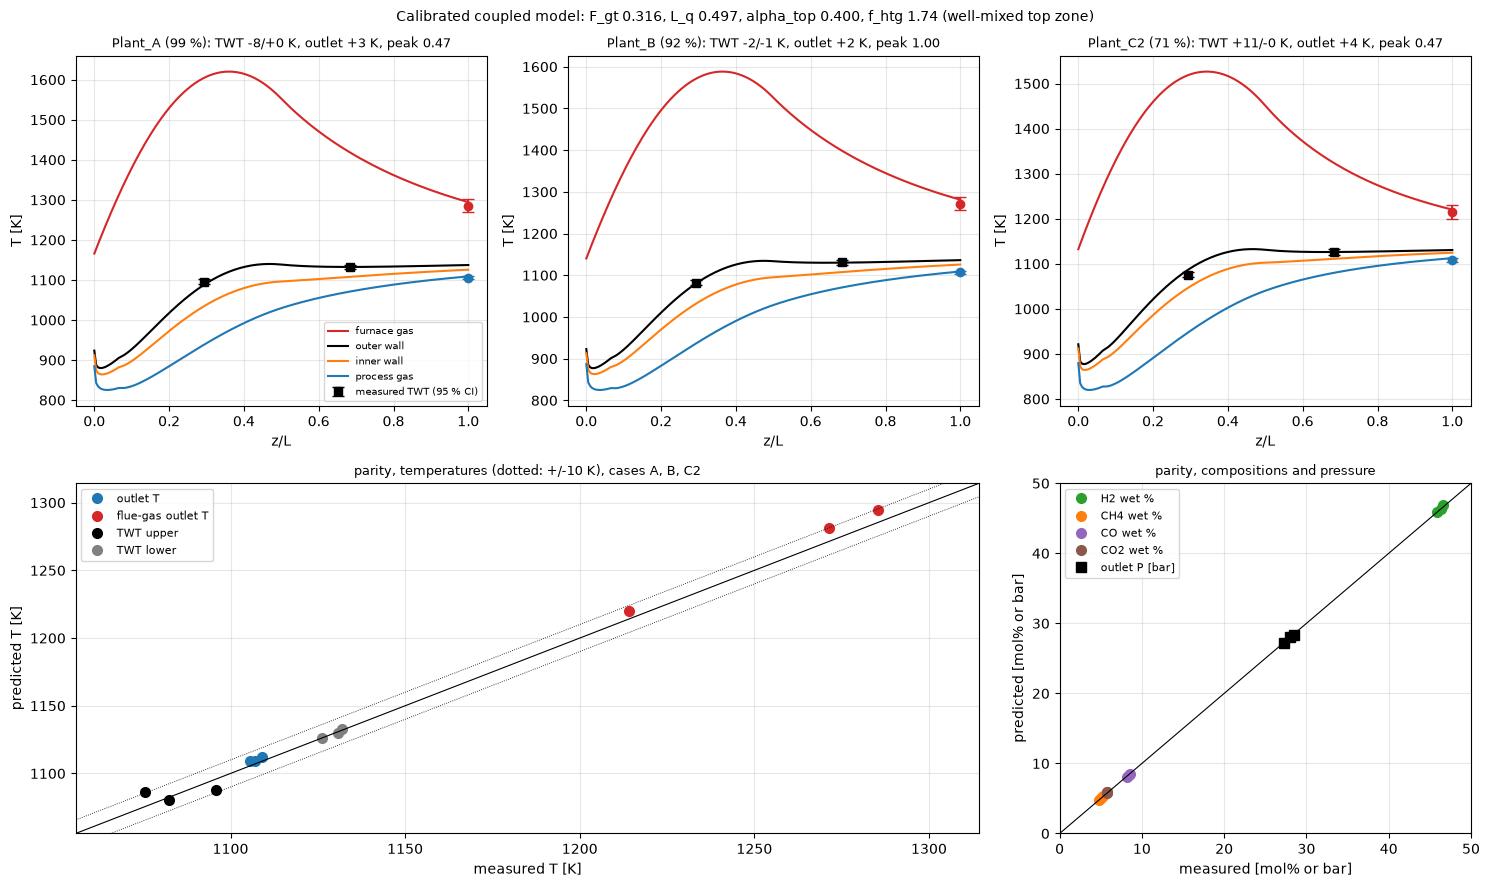

In [5]:
fig = plt.figure(figsize=(15, 9))
gs = fig.add_gridspec(2, 3)
axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
pred_all, meas_all, lab_all = [], [], []
for ax, row in zip(axes, rows):
    res = lc.run_case(row, p_fit); c = lc.compare(row, res); zf = res.z_frac
    ax.plot(zf, res.T_fg, color="C3", label="furnace gas"); ax.plot(zf, res.T_wo, color="k", label="outer wall")
    ax.plot(zf, res.T_wi, color="C1", label="inner wall"); ax.plot(zf, res.tube.T, color="C0", label="process gas")
    ax.errorbar([row.TWT_upper_frac, row.TWT_lower_frac], [row.TWT_upper_K, row.TWT_lower_K], yerr=1.96 * row.sigma_TWT_K, fmt="s", color="k", ms=6, capsize=4, label="measured TWT (95 % CI)")
    ax.errorbar([1.0], [row.out_T_K], yerr=1.96 * row.sigma_out_T_K, fmt="o", color="C0", ms=6, capsize=4)
    ax.errorbar([1.0], [row.flue_out_T_K], yerr=1.96 * row.sigma_flue_out_T_K, fmt="o", color="C3", ms=6, capsize=4)
    ax.set_title(f"{row.case} ({row.plant_rate_pct} %): TWT {c['TWT_upper_K']['difference']:+.0f}/{c['TWT_lower_K']['difference']:+.0f} K, outlet {c['out_T_K']['difference']:+.0f} K, peak {c['TWT_peak']['z_frac']:.2f}", fontsize=9)
    ax.set_xlabel("z/L"); ax.set_ylabel("T [K]"); ax.grid(alpha=0.3)
    for q in cal.QUANTITIES:
        pred_all.append(c[q]["predicted"]); meas_all.append(c[q]["measured"]); lab_all.append((row.case, q))
axes[0].legend(fontsize=7, loc="lower right")
axp = fig.add_subplot(gs[1, :2]); axq = fig.add_subplot(gs[1, 2])
tq = [q for q in cal.QUANTITIES if q.endswith("_K")]
mT = [mv for (cs, q), mv in zip(lab_all, meas_all) if q in tq]; pT = [pv for (cs, q), pv in zip(lab_all, pred_all) if q in tq]
for q, col, lab in (("out_T_K", "C0", "outlet T"), ("flue_out_T_K", "C3", "flue-gas outlet T"), ("TWT_upper_K", "k", "TWT upper"), ("TWT_lower_K", "grey", "TWT lower")):
    m = [mv for (cs, qq), mv in zip(lab_all, meas_all) if qq == q]; pr = [pv for (cs, qq), pv in zip(lab_all, pred_all) if qq == q]
    axp.plot(m, pr, "o", color=col, ms=7, label=lab)
lo, hi = min(mT + pT) - 20, max(mT + pT) + 20
axp.plot([lo, hi], [lo, hi], "k-", lw=0.8); axp.plot([lo, hi], [lo + 10, hi + 10], "k:", lw=0.6); axp.plot([lo, hi], [lo - 10, hi - 10], "k:", lw=0.6)
axp.set_xlim(lo, hi); axp.set_ylim(lo, hi); axp.set_xlabel("measured T [K]"); axp.set_ylabel("predicted T [K]"); axp.legend(fontsize=8); axp.grid(alpha=0.3)
axp.set_title("parity, temperatures (dotted: +/-10 K), cases A, B, C2", fontsize=9)
for q, col, lab in (("out_x_H2_wet_molpct", "C2", "H2 wet %"), ("out_x_CH4_wet_molpct", "C1", "CH4 wet %"), ("out_x_CO_wet_molpct", "C4", "CO wet %"), ("out_x_CO2_wet_molpct", "C5", "CO2 wet %")):
    m = [mv for (cs, qq), mv in zip(lab_all, meas_all) if qq == q]; pr = [pv for (cs, qq), pv in zip(lab_all, pred_all) if qq == q]
    axq.plot(m, pr, "o", color=col, ms=7, label=lab)
m = [mv / 1e5 for (cs, qq), mv in zip(lab_all, meas_all) if qq == "out_P_Pa"]; pr = [pv / 1e5 for (cs, qq), pv in zip(lab_all, pred_all) if qq == "out_P_Pa"]
axq.plot(m, pr, "s", color="k", ms=7, label="outlet P [bar]")
axq.plot([0, 50], [0, 50], "k-", lw=0.8); axq.set_xlim(0, 50); axq.set_ylim(0, 50)
axq.set_xlabel("measured [mol% or bar]"); axq.set_ylabel("predicted [mol% or bar]"); axq.legend(fontsize=8); axq.grid(alpha=0.3)
axq.set_title("parity, compositions and pressure", fontsize=9)
fig.suptitle(f"Calibrated coupled model: F_gt {p_fit.F_gt:.3f}, L_q {p_fit.L_q:.3f}, alpha_top {p_fit.alpha_top:.3f}, f_htg {p_fit.f_htg:.2f} (well-mixed top zone)", fontsize=10)
fig.tight_layout()
out = Path("..") / "paper" / "figures" / "fig05_latham_calibrated.png"
fig.savefig(out, dpi=150); print("saved", out.resolve()); plt.show()


In [6]:
def py(o):
    if isinstance(o, dict): return {str(k): py(v) for k, v in o.items() if k not in ("result", "jac", "fun", "cov", "corr")}
    if isinstance(o, (list, tuple)): return [py(v) for v in o]
    if isinstance(o, np.ndarray): return [py(v) for v in o.tolist()]
    if isinstance(o, (np.floating, np.integer)): return o.item()
    if isinstance(o, np.bool_): return bool(o)
    return o
fit_path = Path("..") / "data" / "literature_validation" / "latham_fit.yaml"
doc = yaml.safe_load(fit_path.read_text())
doc["calibration"] = {
    "cases": list(cal.CAL_CASES), "excluded": {"Plant_C1": "feed flow equals air flow to four digits and exceeds Plant A by 22 % at a lower rate; thesis table transcription error (README)"},
    "inlet_mode": "well_mixed_top",
    "fitted_parameters": list(cal.PARAM_NAMES), "bounds": {k: list(v) for k, v in cal.BOUNDS.items()},
    "fixed": {"activity": p_fit.activity, "voidage": p_fit.voidage, "eta": p_fit.eta, "eta_top": p_fit.eta_top, "f_ctube": p_fit.f_ctube, "wall_thickness_m": p_fit.wall_thickness_m},
    "objective": "sum over cases and quantities of ((pred - meas)/s)^2; s: outlet T 3 K, outlet P 0.1 bar, wet H2/CH4/CO/CO2 0.3 mol%, flue-gas outlet T 10 K, TWT per-case thesis sigma (3 K, fallback 20 K)",
    "multistart": {"n_lhs_starts": 5, "seed": 7, "extra_start": "Latham Table 6", "all_fits": py([{k: f[k] for k in ("x0", "params", "chi2", "n_evals", "status", "message", "at_bound")} for f in ms["fits"]]),
                   "distinct_optima": py([{"params": f["params"], "chi2": f["chi2"]} for f in ms["distinct_optima"]])},
    "best_fit": {"params": py(best["params"]), "chi2": best["chi2"], "n_obs": best["n_obs"], "at_bound": best["at_bound"],
                 "covariance": py({k: cov[k] for k in ("se", "ci95", "t_975", "dof", "reduced_chi2", "corr_table", "high_correlation_pairs", "condition_number_JtJ")}),
                 "errors_pred_minus_meas": py(err_all),
                 "alpha_i_plant_A_midheight_W_m2K": alpha_mid, "alpha_i_plant_A_range_W_m2K": [float(resA.tube.alpha_i.min()), float(resA.tube.alpha_i.max())],
                 "full_parameters": asdict(p_fit)},
    "leave_one_out_cv": py(cv),
    "latham_2011_table10_reference": "outlet T within <1 to 4 K, TWT 3 to 22 K",
    "sensitivity_plant_A": py({"description": "one-at-a-time changes of the four outputs relative to the calibrated reference (first row = reference absolute values)",
                               "table": sens.reset_index().to_dict(orient="records")}),
}
fit_path.write_text(yaml.safe_dump(doc, sort_keys=False, default_flow_style=False, width=130))
print("wrote calibration section to latham_fit.yaml")


wrote calibration section to latham_fit.yaml
